In [76]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
import matplotlib
matplotlib.rcParams["figure.figsize"] = (20,10)

In [77]:
df1 = pd.read_csv("Real_Estate_Dataset.csv")
df1.head()

,PRT_ID,AREA,INT_SQFT,DIST_MAINROAD,N_BEDROOM,N_BATHROOM,PARK_FACIL,BUILDTYPE,STREET,SALES_PRICE
0,P03210,Karapakkam,1004,131,1.0,1.0,Yes,Commercial,Paved,7600000
1,P09411,Anna Nagar,1986,26,2.0,1.0,No,Commercial,Gravel,21717770
2,P01812,Adyar,909,70,1.0,1.0,Yes,Commercial,Gravel,13159200
3,P05346,Velachery,1855,14,3.0,2.0,No,Others,Paved,9630290
4,P06210,Karapakkam,1226,84,1.0,1.0,Yes,Others,Gravel,7406250


In [78]:
df1.shape

(7109, 10)

# Data Cleaning
Removing null values and merging similar fields with spelling errors

In [80]:
df1.isnull().sum()

PRT_ID           0
AREA             0
INT_SQFT         0
DIST_MAINROAD    0
N_BEDROOM        1
N_BATHROOM       5
PARK_FACIL       0
BUILDTYPE        0
STREET           0
SALES_PRICE      0
dtype: int64

In [81]:
df1 = df1.dropna()
df1.isnull().sum()

PRT_ID           0
AREA             0
INT_SQFT         0
DIST_MAINROAD    0
N_BEDROOM        0
N_BATHROOM       0
PARK_FACIL       0
BUILDTYPE        0
STREET           0
SALES_PRICE      0
dtype: int64

In [82]:
df1.shape

(7103, 10)

In [83]:
df1['BUILDTYPE'] = df1['BUILDTYPE'].replace('Comercial', 'Commercial')
df1['BUILDTYPE'] = df1['BUILDTYPE'].replace('Other', 'Others')
df1['BUILDTYPE'].value_counts()

BUILDTYPE
House         2443
Others        2331
Commercial    2329
Name: count, dtype: int64

In [84]:
df1['STREET'] = df1['STREET'].replace('NoAccess', 'No Access')
df1['STREET'] = df1['STREET'].replace('Pavd', 'Paved')
df1['STREET'].value_counts()

STREET
Paved        2570
Gravel       2518
No Access    2015
Name: count, dtype: int64

In [85]:
df1['PARK_FACIL'] = df1['PARK_FACIL'].replace('Noo', 'No')
df1['PARK_FACIL'].value_counts()

PARK_FACIL
Yes    3584
No     3519
Name: count, dtype: int64

In [86]:
df1['AREA'] = df1['AREA'].replace('Karapakam', 'Karapakkam')
df1['AREA'] = df1['AREA'].replace('KKNagar', 'KK Nagar')
df1['AREA'] = df1['AREA'].replace('Ana Nagar', 'Anna Nagar')
df1['AREA'] = df1['AREA'].replace('TNagar', 'T Nagar')
df1['AREA'] = df1['AREA'].replace('Adyr', 'Adyar')
df1['AREA'] = df1['AREA'].replace('Velchery', 'Velachery')
df1['AREA'] = df1['AREA'].replace('Ann Nagar', 'Anna Nagar')
df1['AREA'] = df1['AREA'].replace('Chrompt', 'Chrompet')
df1['AREA'] = df1['AREA'].replace('Chrmpet', 'Chrompet')
df1['AREA'] = df1['AREA'].replace('Chormpet', 'Chrompet')
df1['AREA'].value_counts()

AREA
Chrompet      1699
Karapakkam    1366
KK Nagar       997
Velachery      981
Anna Nagar     785
Adyar          774
T Nagar        501
Name: count, dtype: int64

In [87]:
df1.dtypes

PRT_ID            object
AREA              object
INT_SQFT           int64
DIST_MAINROAD      int64
N_BEDROOM        float64
N_BATHROOM       float64
PARK_FACIL        object
BUILDTYPE         object
STREET            object
SALES_PRICE        int64
dtype: object

In [88]:
df1['N_BEDROOM'] = df1['N_BEDROOM'].astype('int64')
df1['N_BATHROOM'] = df1['N_BATHROOM'].astype('int64')
df1.dtypes

PRT_ID           object
AREA             object
INT_SQFT          int64
DIST_MAINROAD     int64
N_BEDROOM         int64
N_BATHROOM        int64
PARK_FACIL       object
BUILDTYPE        object
STREET           object
SALES_PRICE       int64
dtype: object

In [89]:
df1.head()

,PRT_ID,AREA,INT_SQFT,DIST_MAINROAD,N_BEDROOM,N_BATHROOM,PARK_FACIL,BUILDTYPE,STREET,SALES_PRICE
0,P03210,Karapakkam,1004,131,1,1,Yes,Commercial,Paved,7600000
1,P09411,Anna Nagar,1986,26,2,1,No,Commercial,Gravel,21717770
2,P01812,Adyar,909,70,1,1,Yes,Commercial,Gravel,13159200
3,P05346,Velachery,1855,14,3,2,No,Others,Paved,9630290
4,P06210,Karapakkam,1226,84,1,1,Yes,Others,Gravel,7406250


#Checking Outliers in the numerical values

In [91]:
def is_float(x):
    try:
        float(x)
    except:
        return False
    return True

In [92]:
df1[~df1['INT_SQFT'].apply(is_float)]

,PRT_ID,AREA,INT_SQFT,DIST_MAINROAD,N_BEDROOM,N_BATHROOM,PARK_FACIL,BUILDTYPE,STREET,SALES_PRICE


In [93]:
df1.dtypes

PRT_ID           object
AREA             object
INT_SQFT          int64
DIST_MAINROAD     int64
N_BEDROOM         int64
N_BATHROOM        int64
PARK_FACIL       object
BUILDTYPE        object
STREET           object
SALES_PRICE       int64
dtype: object

In [94]:
df2=df1.copy()
df2['PRICE_PER_SQFT']=df2['SALES_PRICE']/df2['INT_SQFT']
df2.head()

,PRT_ID,AREA,INT_SQFT,DIST_MAINROAD,N_BEDROOM,N_BATHROOM,PARK_FACIL,BUILDTYPE,STREET,SALES_PRICE,PRICE_PER_SQFT
0,P03210,Karapakkam,1004,131,1,1,Yes,Commercial,Paved,7600000,7569.721116
1,P09411,Anna Nagar,1986,26,2,1,No,Commercial,Gravel,21717770,10935.433031
2,P01812,Adyar,909,70,1,1,Yes,Commercial,Gravel,13159200,14476.567657
3,P05346,Velachery,1855,14,3,2,No,Others,Paved,9630290,5191.530997
4,P06210,Karapakkam,1226,84,1,1,Yes,Others,Gravel,7406250,6040.986949


In [95]:
unique_values = df2['PRICE_PER_SQFT'].unique()
print(unique_values)

[ 7569.72111554 10935.43303122 14476.56765677 ...  5174.35563817
 10809.40279543  5261.85654008]


# VISUALIZATION OF CLEANED DATA

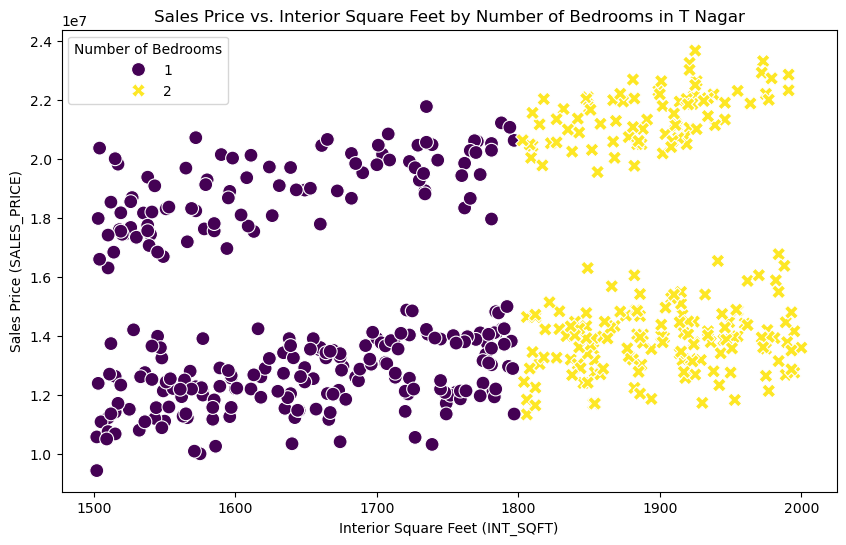

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the desired location for filtering
location = 'T Nagar'  # Replace 'Desired_Area' with the actual area you want to filter by

# Filter data based on AREA
filtered_data = df2[df2['AREA'] == location]

# Check if there are any rows for the given AREA
if filtered_data.empty:
    print(f"No data available for area: {location}")
else:
    # Create a scatter plot with hue based on N_BEDROOM
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=filtered_data, x='INT_SQFT', y='SALES_PRICE', hue='N_BEDROOM', palette='viridis', style='N_BEDROOM', s=100)

    # Set plot labels and title
    plt.xlabel('Interior Square Feet (INT_SQFT)')
    plt.ylabel('Sales Price (SALES_PRICE)')
    plt.title(f'Sales Price vs. Interior Square Feet by Number of Bedrooms in {location}')

    # Show legend and plot
    plt.legend(title='Number of Bedrooms')
    plt.show()



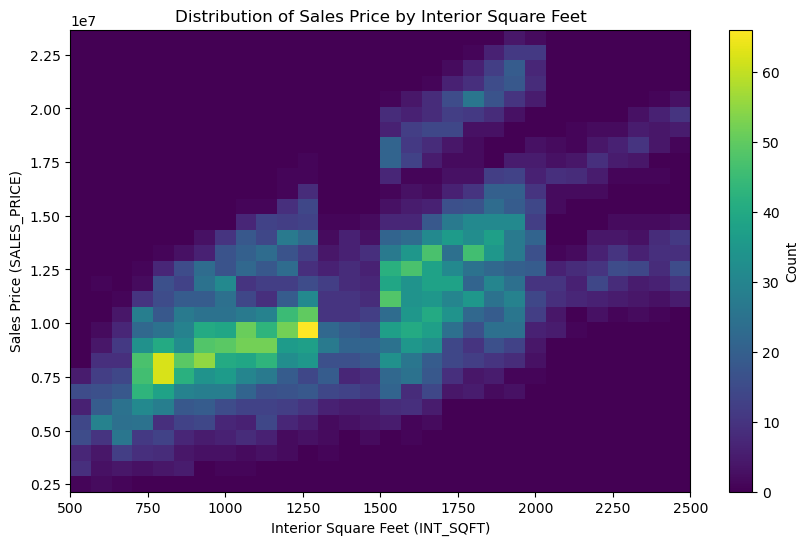

In [98]:
import matplotlib.pyplot as plt

# Plot histogram for Sales Price against Interior Square Feet
plt.figure(figsize=(10, 6))
plt.hist2d(df2['INT_SQFT'], df1['SALES_PRICE'], bins=30, cmap='viridis')

# Add color bar
plt.colorbar(label='Count')

# Set labels and title
plt.xlabel('Interior Square Feet (INT_SQFT)')
plt.ylabel('Sales Price (SALES_PRICE)')
plt.title('Distribution of Sales Price by Interior Square Feet')

# Display plot
plt.show()


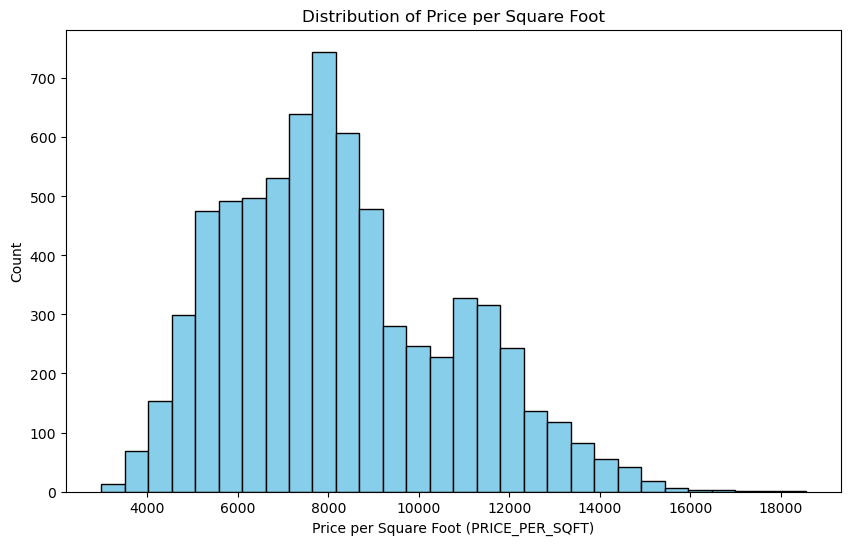

In [99]:
import matplotlib.pyplot as plt

# Plot histogram for PRICE_PER_SQFT
plt.figure(figsize=(10, 6))
plt.hist(df2['PRICE_PER_SQFT'], bins=30, color='skyblue', edgecolor='black')

# Set labels and title
plt.xlabel('Price per Square Foot (PRICE_PER_SQFT)')
plt.ylabel('Count')
plt.title('Distribution of Price per Square Foot')

# Display plot
plt.show()


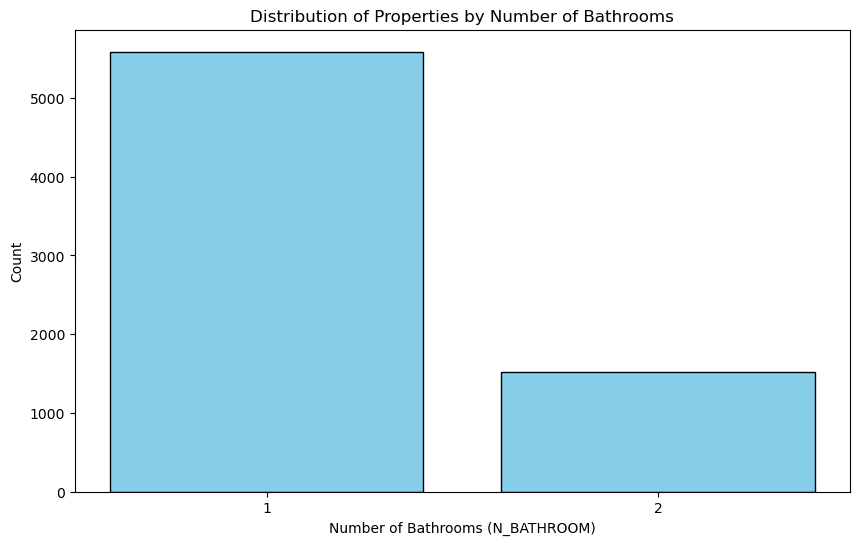

In [100]:
import matplotlib.pyplot as plt

# Filter data for properties with 1 and 2 bathrooms
bathrooms_1_2 = df2[df1['N_BATHROOM'].isin([1, 2])]

# Plot histogram with the same color for 1 and 2 bathrooms
plt.figure(figsize=(10, 6))
plt.hist(bathrooms_1_2['N_BATHROOM'], bins=[0.5, 1.5, 2.5], color='skyblue', edgecolor='black', rwidth=0.8)

# Set labels, title, and x-axis ticks to show only 1 and 2
plt.xlabel('Number of Bathrooms (N_BATHROOM)')
plt.ylabel('Count')
plt.title('Distribution of Properties by Number of Bathrooms')
plt.xticks([1, 2])

# Display plot
plt.show()

Features ordered by correlation with target variable:
INT_SQFT         0.612026
N_BEDROOM        0.330933
N_BATHROOM       0.108884
DIST_MAINROAD    0.018679
Name: SALES_PRICE, dtype: float64


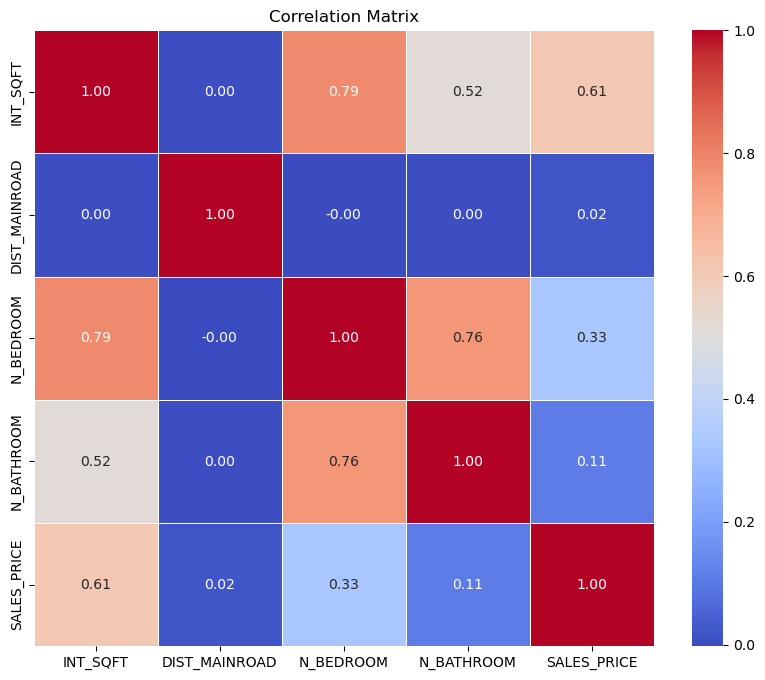

In [101]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df2 is your DataFrame and 'SALES_PRICE' is the target variable
target_variable = 'SALES_PRICE'

# Selecting only numeric columns and dropping 'PRICE_PER_SQFT'
numeric_df = df2.select_dtypes(include=['number']).drop(columns=['PRICE_PER_SQFT'])

# Calculating the correlation matrix
correlation_matrix = numeric_df.corr()

# Extracting correlations with the target variable and sorting
correlations_with_target = correlation_matrix[target_variable].drop(target_variable)
sorted_features = correlations_with_target.abs().sort_values(ascending=False)

# Displaying the sorted features and their correlations
print("Features ordered by correlation with target variable:")
print(sorted_features)

# Plotting the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()



# MODEL BUILDING

In [103]:
# Create df3 by dropping specified columns from df2
df3 = df2.drop(['PRT_ID', 'PRICE_PER_SQFT'], axis=1)
# Display the first few rows of df3
df3.head()


,AREA,INT_SQFT,DIST_MAINROAD,N_BEDROOM,N_BATHROOM,PARK_FACIL,BUILDTYPE,STREET,SALES_PRICE
0,Karapakkam,1004,131,1,1,Yes,Commercial,Paved,7600000
1,Anna Nagar,1986,26,2,1,No,Commercial,Gravel,21717770
2,Adyar,909,70,1,1,Yes,Commercial,Gravel,13159200
3,Velachery,1855,14,3,2,No,Others,Paved,9630290
4,Karapakkam,1226,84,1,1,Yes,Others,Gravel,7406250


In [104]:
import pandas as pd

# Create dummy variables for PARK_FACIL, BUILDTYPE, STREET, and AREA in df3
df3 = pd.get_dummies(df3, columns=['PARK_FACIL', 'BUILDTYPE', 'STREET', 'AREA'], drop_first=True)

# Display the first few rows of the new DataFrame with dummy variables
df3.head()


,INT_SQFT,DIST_MAINROAD,N_BEDROOM,N_BATHROOM,SALES_PRICE,PARK_FACIL_Yes,BUILDTYPE_House,BUILDTYPE_Others,STREET_No Access,STREET_Paved,AREA_Anna Nagar,AREA_Chrompet,AREA_KK Nagar,AREA_Karapakkam,AREA_T Nagar,AREA_Velachery
0,1004,131,1,1,7600000,True,False,False,False,True,False,False,False,True,False,False
1,1986,26,2,1,21717770,False,False,False,False,False,True,False,False,False,False,False
2,909,70,1,1,13159200,True,False,False,False,False,False,False,False,False,False,False
3,1855,14,3,2,9630290,False,False,True,False,True,False,False,False,False,False,True
4,1226,84,1,1,7406250,True,False,True,False,False,False,False,False,True,False,False


In [105]:
df3.dtypes

INT_SQFT            int64
DIST_MAINROAD       int64
N_BEDROOM           int64
N_BATHROOM          int64
SALES_PRICE         int64
PARK_FACIL_Yes       bool
BUILDTYPE_House      bool
BUILDTYPE_Others     bool
STREET_No Access     bool
STREET_Paved         bool
AREA_Anna Nagar      bool
AREA_Chrompet        bool
AREA_KK Nagar        bool
AREA_Karapakkam      bool
AREA_T Nagar         bool
AREA_Velachery       bool
dtype: object

## Linear Regression

In [107]:
x=df3.drop('SALES_PRICE',axis='columns')
x.head()

,INT_SQFT,DIST_MAINROAD,N_BEDROOM,N_BATHROOM,PARK_FACIL_Yes,BUILDTYPE_House,BUILDTYPE_Others,STREET_No Access,STREET_Paved,AREA_Anna Nagar,AREA_Chrompet,AREA_KK Nagar,AREA_Karapakkam,AREA_T Nagar,AREA_Velachery
0,1004,131,1,1,True,False,False,False,True,False,False,False,True,False,False
1,1986,26,2,1,False,False,False,False,False,True,False,False,False,False,False
2,909,70,1,1,True,False,False,False,False,False,False,False,False,False,False
3,1855,14,3,2,False,False,True,False,True,False,False,False,False,False,True
4,1226,84,1,1,True,False,True,False,False,False,False,False,True,False,False


In [108]:
y=df3.SALES_PRICE
y.head()

0     7600000
1    21717770
2    13159200
3     9630290
4     7406250
Name: SALES_PRICE, dtype: int64

In [109]:
from sklearn.model_selection import train_test_split
x_train,x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=10)

In [110]:
from sklearn.linear_model import LinearRegression
lr_clf = LinearRegression()
lr_clf.fit(x_train,y_train)
lr_score=lr_clf.score(x_test,y_test)
print(f' Linear Regression R^2 Score: {lr_score}')

 Linear Regression R^2 Score: 0.9049934906300642


In [111]:
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_val_score
cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
cv_scores=cross_val_score(LinearRegression(),x,y,cv=cv)
print("Cross-Validation R² Scores:", cv_scores)
print("Average Cross-Validation R² Score:", cv_scores.mean())

Cross-Validation R² Scores: [0.90768682 0.90828132 0.90747553 0.9086935  0.9023408 ]
Average Cross-Validation R² Score: 0.9068955919583461


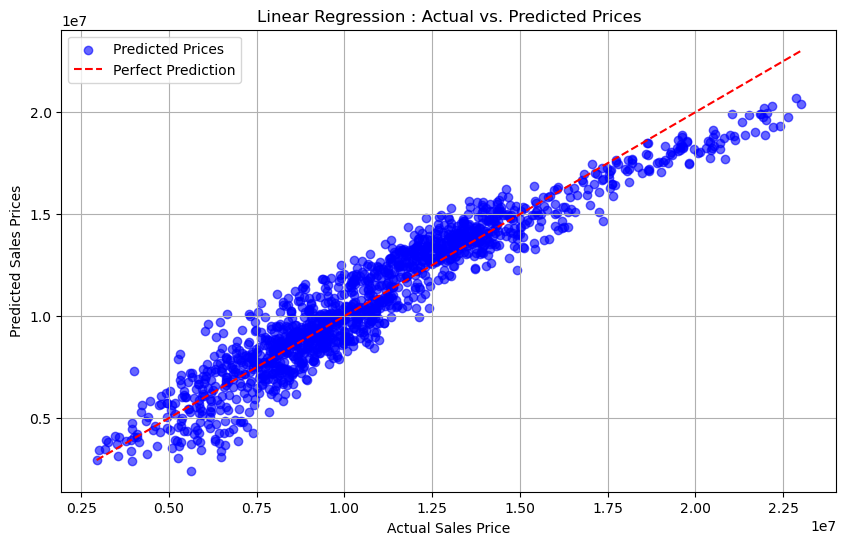

In [112]:
import matplotlib.pyplot as plt

# Predict using the model
y_pred = lr_clf.predict(x_test)

# Create the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6, label='Predicted Prices')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Perfect Prediction')  # Diagonal line
plt.xlabel('Actual Sales Price')
plt.ylabel('Predicted Sales Prices')
plt.title('Linear Regression : Actual vs. Predicted Prices')
plt.legend()
plt.grid()
plt.show()

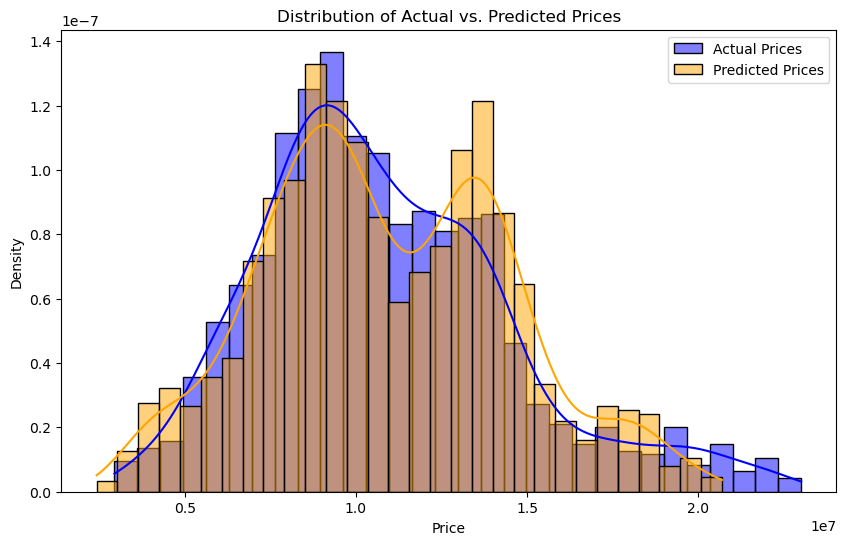

In [113]:
# Ensure plots are displayed inline in Jupyter
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns

# Create the histogram plot
plt.figure(figsize=(10, 6))
sns.histplot(y_test, color='blue', label='Actual Prices', kde=True, stat='density', bins=30, alpha=0.5)
sns.histplot(y_pred, color='orange', label='Predicted Prices', kde=True, stat='density', bins=30, alpha=0.5)

plt.xlabel('Price')
plt.ylabel('Density')
plt.title('Distribution of Actual vs. Predicted Prices')
plt.legend()
plt.show()  # Displays the histogram



## Random Forest

In [115]:
X=x
Y=y

In [116]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Split the dataset into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=10)

# Initialize the Random Forest Regressor
rf_clf = RandomForestRegressor(n_estimators=100, random_state=10)

# Train the model
rf_clf.fit(X_train, Y_train)

# Evaluate the model's performance
rf_score = rf_clf.score(X_test, Y_test)

# Print the R^2 score
print(f' Random forest R^2 Score: {rf_score}')


 Random forest R^2 Score: 0.935536306291617


In [117]:
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor

# Initialize ShuffleSplit
cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)

# Perform cross-validation with Random Forest Regressor
cv_scores = cross_val_score(RandomForestRegressor(n_estimators=100, random_state=0), X, Y, cv=cv)

# Print the cross-validation scores and the average score
print("Cross-Validation R² Scores:", cv_scores)
print("Average Cross-Validation R² Score:", cv_scores.mean())


Cross-Validation R² Scores: [0.93737695 0.93952822 0.93194287 0.93789617 0.9326159 ]
Average Cross-Validation R² Score: 0.9358720233911202


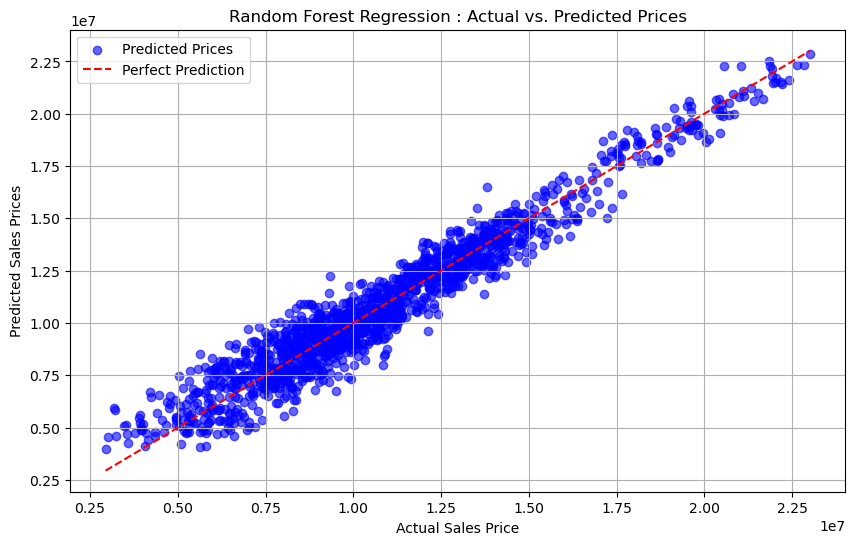

In [118]:
import matplotlib.pyplot as plt

# Predict using the model
Y_pred = rf_clf.predict(X_test)

# Create the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(Y_test, Y_pred, color='blue', alpha=0.6, label='Predicted Prices')
plt.plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)], color='red', linestyle='--', label='Perfect Prediction')  # Diagonal line
plt.xlabel('Actual Sales Price')
plt.ylabel('Predicted Sales Prices')
plt.title('Random Forest Regression : Actual vs. Predicted Prices')
plt.legend()
plt.grid()
plt.show()



In [156]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, r2_score

N = X  # Features
M = Y  # Target

# Split data into training and testing sets
N_train, N_test, M_train, M_test = train_test_split(N, M, test_size=0.2, random_state=42)

# Define the parameter grid for RandomForestRegressor
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]  # valid options for max_features
}

# Initialize the RandomForestRegressor
rf = RandomForestRegressor()

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=rf, 
    param_grid=param_grid, 
    cv=5, 
    scoring='neg_mean_squared_error', 
    n_jobs=-1, 
    verbose=2
)

# Fit the grid search
grid_search.fit(N_train, M_train)

# Retrieve the best parameters and the corresponding score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

# Print the best parameters and best score
print("Best Parameters:", best_params)
print("Best Score (Negative Mean Squared Error):", best_score)

# Evaluate on the test set
best_rf = grid_search.best_estimator_
M_pred = best_rf.predict(N_test)

# Calculate Mean Squared Error on the test set
mse = mean_squared_error(M_test, M_pred)
print("Mean Squared Error on Test Set:", mse)

# Calculate R-squared score on the test set
r2 = r2_score(M_test, M_pred)
print("R-squared Score on Test Set:", r2)




Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best Parameters: {'max_depth': 20, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
Best Score (Negative Mean Squared Error): -859068387940.854
Mean Squared Error on Test Set: 812204340973.9116
R-squared Score on Test Set: 0.9440545718106826


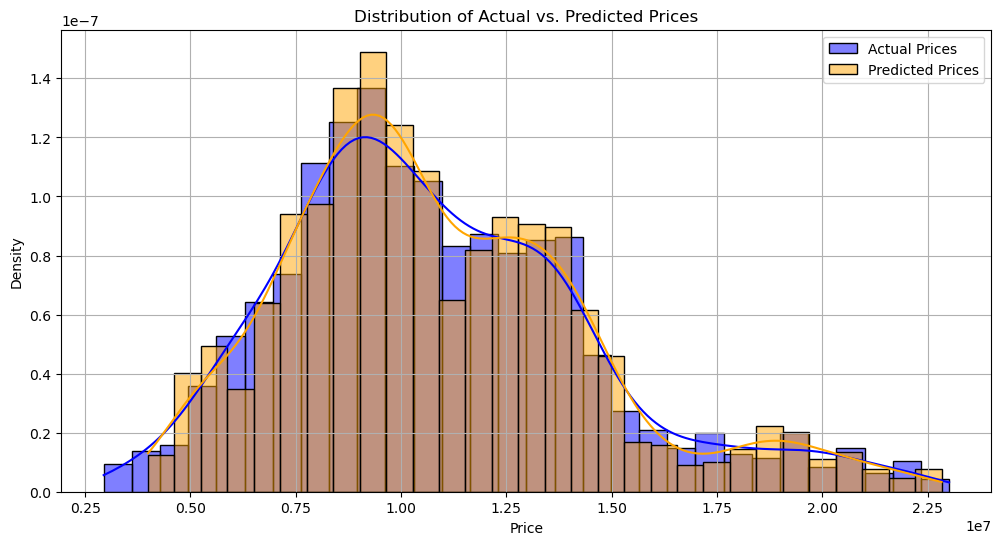

In [158]:
import matplotlib.pyplot as plt
import seaborn as sns

# Predict using the model
Y_pred = rf_clf.predict(X_test)

# Create a histogram to compare actual and predicted prices
plt.figure(figsize=(12, 6))
sns.histplot(Y_test, color='blue', label='Actual Prices', kde=True, stat='density', bins=30, alpha=0.5)
sns.histplot(Y_pred, color='orange', label='Predicted Prices', kde=True, stat='density', bins=30, alpha=0.5)

plt.xlabel('Price')
plt.ylabel('Density')
plt.title('Distribution of Actual vs. Predicted Prices')
plt.legend()
plt.grid()
plt.show()


In [160]:
import pandas as pd

# Assuming df is your DataFrame
print("Columns and Attributes:")
print(df3.info())


Columns and Attributes:
<class 'pandas.core.frame.DataFrame'>
Index: 7103 entries, 0 to 7108
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   INT_SQFT          7103 non-null   int64
 1   DIST_MAINROAD     7103 non-null   int64
 2   N_BEDROOM         7103 non-null   int64
 3   N_BATHROOM        7103 non-null   int64
 4   SALES_PRICE       7103 non-null   int64
 5   PARK_FACIL_Yes    7103 non-null   bool 
 6   BUILDTYPE_House   7103 non-null   bool 
 7   BUILDTYPE_Others  7103 non-null   bool 
 8   STREET_No Access  7103 non-null   bool 
 9   STREET_Paved      7103 non-null   bool 
 10  AREA_Anna Nagar   7103 non-null   bool 
 11  AREA_Chrompet     7103 non-null   bool 
 12  AREA_KK Nagar     7103 non-null   bool 
 13  AREA_Karapakkam   7103 non-null   bool 
 14  AREA_T Nagar      7103 non-null   bool 
 15  AREA_Velachery    7103 non-null   bool 
dtypes: bool(11), int64(5)
memory usage: 409.3 KB
None


## DECISION TREE

In [162]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Assuming df3 contains the features (X) and target (Y) in the following columns:
# Features are all columns except 'SALES_PRICE'
a = df3.drop(columns=['SALES_PRICE'])  # Features
b = df3['SALES_PRICE']  # Target variable

# Splitting the data into training and testing sets
a_train, a_test, b_train, b_test = train_test_split(a, b, test_size=0.2, random_state=42)

# Create a Decision Tree model (can be replaced with other models as needed)
model = DecisionTreeRegressor(random_state=42)

# Fit the model
model.fit(a_train, b_train)

# Predictions
b_pred = model.predict(a_test)

# Calculate MSE and R-squared
mse = mean_squared_error(b_test, b_pred)
r2 = r2_score(b_test, b_pred)

# Display the results
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared: {r2:.2f}")




Mean Squared Error (MSE): 1570511208010.29
R-squared: 0.89


Mean Squared Error (MSE): 1570511208010.29
R-squared: 0.89


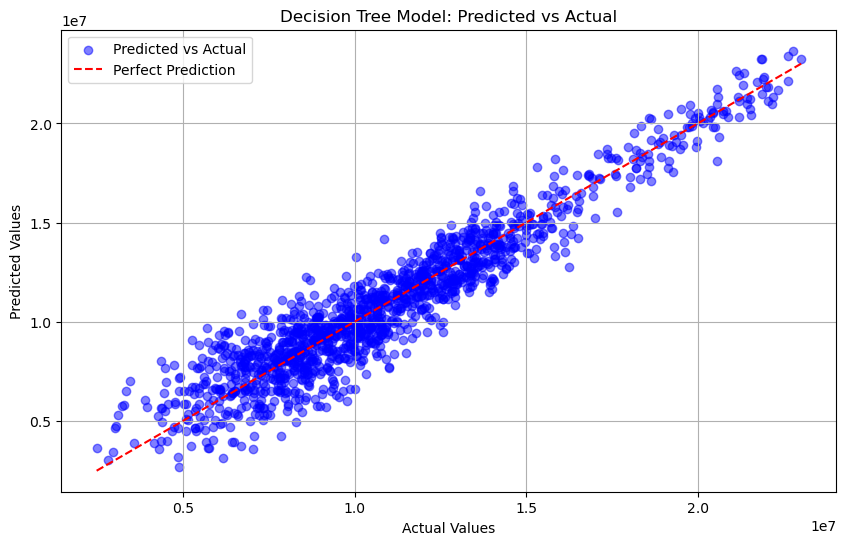

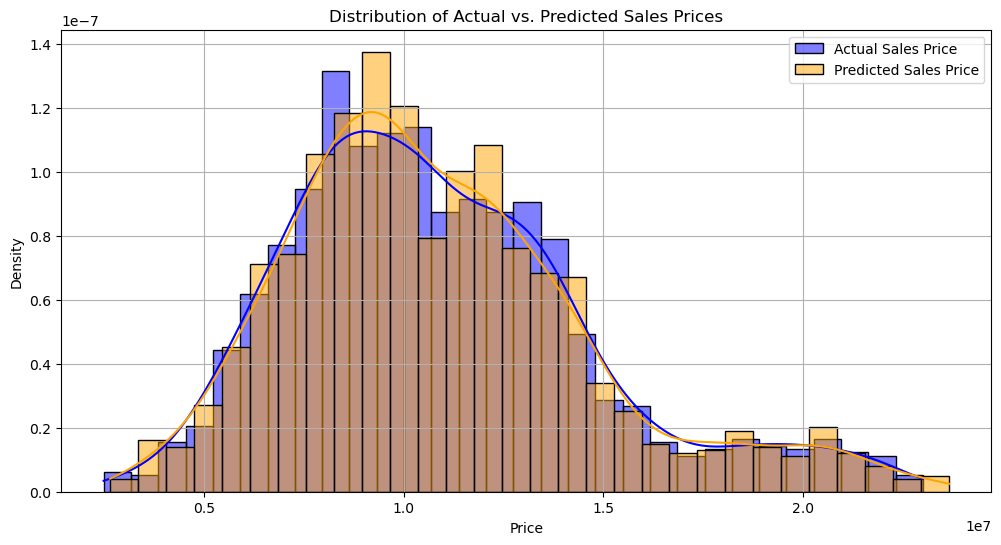

In [164]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Assuming df3 contains the features (X) and target (Y) in the following columns:
# Features are all columns except 'SALES_PRICE'
a = df3.drop(columns=['SALES_PRICE'])  # Features
b = df3['SALES_PRICE']  # Target variable

# Splitting the data into training and testing sets
a_train, a_test, b_train, b_test = train_test_split(a, b, test_size=0.2, random_state=42)

# Create a Decision Tree model (can be replaced with other models as needed)
model = DecisionTreeRegressor(random_state=42)

# Fit the model
model.fit(a_train, b_train)

# Predictions
b_pred = model.predict(a_test)

# Calculate MSE and R-squared
mse = mean_squared_error(b_test, b_pred)
r2 = r2_score(b_test, b_pred)

# Display the results
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared: {r2:.2f}")


import matplotlib.pyplot as plt
import numpy as np

# Plotting the predicted values against the actual values
plt.figure(figsize=(10, 6))
plt.scatter(b_test, b_pred, color='blue', alpha=0.5, label='Predicted vs Actual')
plt.plot([min(b_test), max(b_test)], [min(b_test), max(b_test)], color='red', linestyle='--', label='Perfect Prediction')

# Adding labels and title
plt.title('Decision Tree Model: Predicted vs Actual')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.grid(True)

# Show plot
plt.show()


# Create a histogram to compare actual and predicted sales prices
plt.figure(figsize=(12, 6))

# Plot actual sales price distribution
sns.histplot(b_test, color='blue', label='Actual Sales Price', kde=True, stat='density', bins=30, alpha=0.5)

# Plot predicted sales price distribution
sns.histplot(b_pred, color='orange', label='Predicted Sales Price', kde=True, stat='density', bins=30, alpha=0.5)

# Adding labels and title
plt.xlabel('Price')
plt.ylabel('Density')
plt.title('Distribution of Actual vs. Predicted Sales Prices')

# Display the legend
plt.legend()

# Show grid
plt.grid(True)

# Display the plot
plt.show()




## Light Gradient Boosting Machine

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001396 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 498
[LightGBM] [Info] Number of data points in the train set: 5682, number of used features: 15
[LightGBM] [Info] Start training from score 10899936.935058
R-squared: 0.9488211684998685


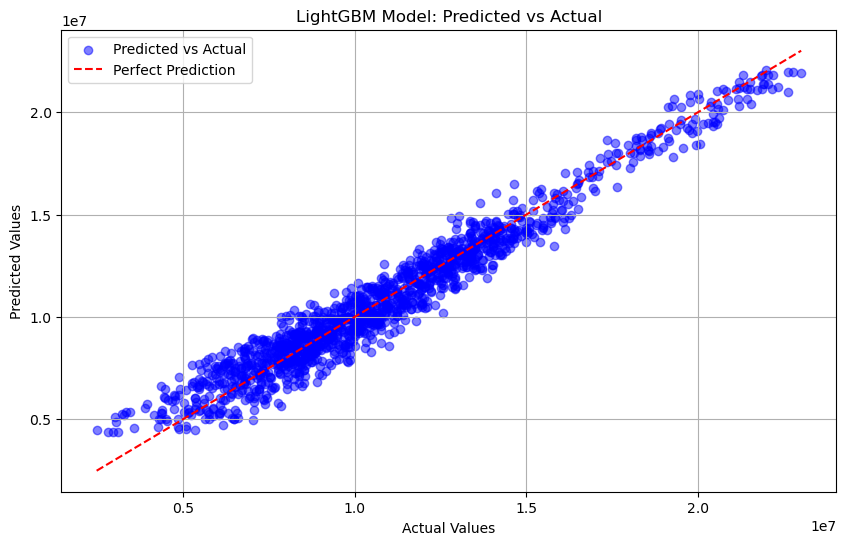

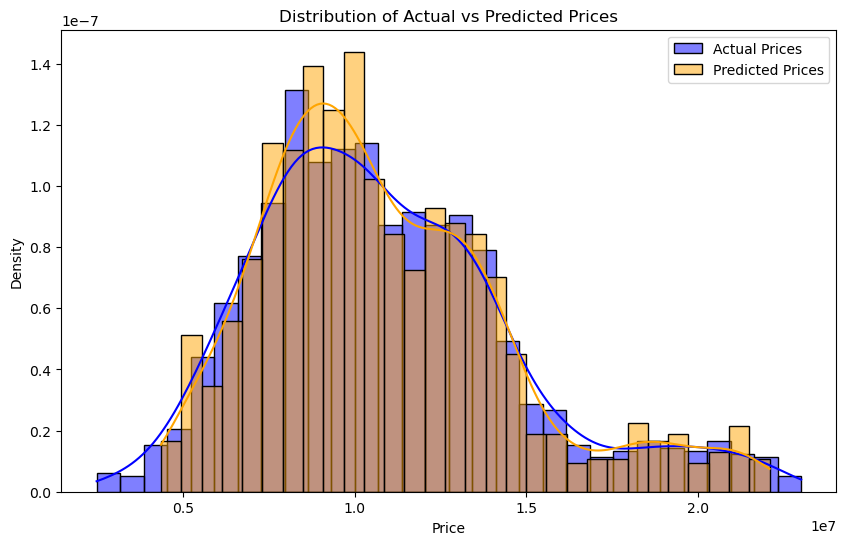

In [168]:
import pickle
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df3' is your DataFrame
# Define the features (c) and target variable (d)
c = df3.drop('SALES_PRICE', axis=1)  # Dropping the target variable 'SALES_PRICE' from the features
d = df3['SALES_PRICE']  # Target variable

# Split the data into training and testing sets
c_train, c_test, d_train, d_test = train_test_split(c, d, test_size=0.2, random_state=42)

# Scale the features using StandardScaler
scaler = StandardScaler()
c_train_scaled = scaler.fit_transform(c_train)
c_test_scaled = scaler.transform(c_test)
# Save the scaler
with open('scaler.pickle', 'wb') as file:
    pickle.dump(scaler, file)

# Create the LightGBM model
lgbm_reg = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, num_leaves=31, max_depth=-1)

# Fit the model
lgbm_reg.fit(c_train_scaled, d_train)

# Make predictions
d_pred = lgbm_reg.predict(c_test_scaled)

# Calculate the R-squared value
r2 = r2_score(d_test, d_pred)

# Print the results
print(f'R-squared: {r2}')

# Plotting the predicted vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(d_test, d_pred, color='blue', alpha=0.5, label='Predicted vs Actual')
plt.plot([min(d_test), max(d_test)], [min(d_test), max(d_test)], color='red', linestyle='--', label='Perfect Prediction')

# Adding labels and title for scatter plot
plt.title('LightGBM Model: Predicted vs Actual')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.grid(True)

# Show scatter plot
plt.show()

# Plotting the histogram for Actual vs Predicted Prices
plt.figure(figsize=(10, 6))
sns.histplot(d_test, color='blue', label='Actual Prices', kde=True, stat='density', bins=30, alpha=0.5)
sns.histplot(d_pred, color='orange', label='Predicted Prices', kde=True, stat='density', bins=30, alpha=0.5)

# Adding labels and title for histogram
plt.xlabel('Price')
plt.ylabel('Density')
plt.title('Distribution of Actual vs Predicted Prices')
plt.legend()

# Show histogram plot
plt.show()


In [176]:
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

n = df3.drop('SALES_PRICE', axis=1)  # Dropping the target variable 'SALES_PRICE' from the features
m = df3['SALES_PRICE']  # Target variable
n_train, n_test, m_train, m_test = train_test_split(n, m, test_size=0.2, random_state=42)

# Define the parameter grid for LGBM
param_grid = {
    'num_leaves': [31, 50],            # Number of leaves in one tree
    'max_depth': [-1, 5],              # Maximum depth of tree
    'learning_rate': [0.05, 0.1],    # Step size for each iteration
    'n_estimators': [100, 300],       # Number of boosting iterations (trees)
}

# Initialize the LightGBM Regressor
lgbm = lgb.LGBMRegressor()

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=lgbm, 
    param_grid=param_grid, 
    cv=5, 
    scoring='neg_mean_squared_error', 
    n_jobs=-1, 
    verbose=2
)

# Fit the grid search
grid_search.fit(n_train, m_train)

# Retrieve the best parameters and the corresponding score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

# Print the best parameters and best score
print("Best Parameters:", best_params)
print("Best Score (Negative Mean Squared Error):", best_score)

# Evaluate on the test set
best_lgbm = grid_search.best_estimator_
m_pred = best_lgbm.predict(n_test)

# Calculate Mean Squared Error on the test set
mse = mean_squared_error(m_test, m_pred)
r2 = r2_score(m_test, m_pred)

# Print MSE and R-squared score on the test set
print("Mean Squared Error on Test Set:", mse)
print("R-squared Score on Test Set:", r2)
    


Fitting 5 folds for each of 16 candidates, totalling 80 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000514 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 486
[LightGBM] [Info] Number of data points in the train set: 5682, number of used features: 15
[LightGBM] [Info] Start training from score 10899936.935058
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

In [170]:
X.columns

Index(['INT_SQFT', 'DIST_MAINROAD', 'N_BEDROOM', 'N_BATHROOM',
       'PARK_FACIL_Yes', 'BUILDTYPE_House', 'BUILDTYPE_Others',
       'STREET_No Access', 'STREET_Paved', 'AREA_Anna Nagar', 'AREA_Chrompet',
       'AREA_KK Nagar', 'AREA_Karapakkam', 'AREA_T Nagar', 'AREA_Velachery'],
      dtype='object')

In [176]:
np.where(X.columns=='AREA_Velachery')[0][0]

14

In [177]:
print(x_train.columns)


Index(['INT_SQFT', 'DIST_MAINROAD', 'N_BEDROOM', 'N_BATHROOM',
       'PARK_FACIL_Yes', 'BUILDTYPE_House', 'BUILDTYPE_Others',
       'STREET_No Access', 'STREET_Paved', 'AREA_Anna Nagar', 'AREA_Chrompet',
       'AREA_KK Nagar', 'AREA_Karapakkam', 'AREA_T Nagar', 'AREA_Velachery'],
      dtype='object')


In [172]:
input_data = {
    'INT_SQFT': [2000],  
    'DIST_MAINROAD': [50],  
    'N_BEDROOM': [3],  
    'N_BATHROOM': [2],  
    'PARK_FACIL_Yes': [0],  
    'BUILDTYPE_House': [0],  
    'BUILDTYPE_Others': [0],  
    'STREET_No Access': [0],  
    'STREET_Paved': [1],  
    'AREA_Anna Nagar': [1],  
    'AREA_Chrompet': [0],  
    'AREA_KK Nagar': [0],  
    'AREA_Karapakkam': [0],  
    'AREA_T Nagar': [0],  
    'AREA_Velachery': [0],  
}

# Convert the input dictionary to a DataFrame
input_df = pd.DataFrame(input_data)

# Make a prediction
predicted_price = lr_clf.predict(input_df)

print("Predicted Sales Price: ", predicted_price[0])


Predicted Sales Price:  19029809.60084343


In [266]:
import pickle
with open('chennai_prices.pickle','wb') as f:
    pickle.dump(lr_clf,f)

In [270]:
import json
columns = {
    'data_columns' : [col.lower() for col in x.columns]
}
with open("columns.json","w") as f:
    f.write(json.dumps(columns))

In [174]:
# New input data (replace this with the actual input data you want to predict)
input_data = {
    'INT_SQFT': [2000],  
    'DIST_MAINROAD': [50],  
    'N_BEDROOM': [3],  
    'N_BATHROOM': [2],  
    'PARK_FACIL_Yes': [1],  
    'BUILDTYPE_House': [0],  
    'BUILDTYPE_Others': [1],  
    'STREET_No Access': [0],  
    'STREET_Paved': [0],  
    'AREA_Anna Nagar': [0],  
    'AREA_Chrompet': [0],  
    'AREA_KK Nagar': [0],  
    'AREA_Karapakkam': [0],  
    'AREA_T Nagar': [0],  
    'AREA_Velachery': [1],  
}

# Convert the input dictionary to a DataFrame
input_df = pd.DataFrame(input_data)

# Scale the input data using the same scaler used for training data
input_scaled = scaler.transform(input_df)

# Use the trained LightGBM model to predict the price
predicted_price = lgbm_reg.predict(input_scaled)

# Print the predicted sales price
print(f"Predicted Sales Price: {predicted_price[0]}")


Predicted Sales Price: 11217538.167865684


In [319]:
import pickle

# Save the trained LightGBM model to a file
with open('chennai_prices_lgbm.pickle', 'wb') as f:
    pickle.dump(lgbm_reg, f)
